In [9]:

DATASET_DIR = r"D:\Shalviii\2 month project\Plant disease detection"   
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42
# Backbone: "efficientnetb0" or "mobilenetv2"
FEATURE_BACKBONE = "efficientnetb0"
# XGBoost
N_TREES          = 600
MAX_DEPTH        = 8
LEARNING_RATE    = 0.05
SUBSAMPLE        = 0.9
COLSAMPLE_BYTREE = 0.9
TREE_METHOD      = "hist"       
USE_CLASS_WEIGHTS = True
MODEL_OUT  = "xgb_plant_disease_model.json"
LABELS_OUT = "label_map.json"


Step1-Imports

Step1-Imports

In [10]:
import os, json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
import tensorflow as tf


Step 2 — Load image folders as tf.data.Dataset

In [11]:
def build_image_ds(split_dir, image_size, batch_size, seed, shuffle=False):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        split_dir,
        labels="inferred",
        label_mode="int",
        image_size=image_size,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=seed
    )
    return ds, ds.class_names

train_path = os.path.join(DATASET_DIR, "train")
valid_path = os.path.join(DATASET_DIR, "valid")
test_path  = os.path.join(DATASET_DIR, "test")

assert os.path.isdir(train_path), f"Missing {train_path}"
assert os.path.isdir(valid_path), f"Missing {valid_path}"
assert os.path.isdir(test_path),  f"Missing {test_path}"

train_ds, class_names = build_image_ds(train_path, IMG_SIZE, BATCH_SIZE, SEED, shuffle=True)
valid_ds, _          = build_image_ds(valid_path, IMG_SIZE, BATCH_SIZE, SEED, shuffle=False)
test_ds,  _          = build_image_ds(test_path,  IMG_SIZE, BATCH_SIZE, SEED, shuffle=False)

num_classes = len(class_names)
print(f"Found {num_classes} classes.")


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found 38 files belonging to 1 classes.
Found 38 classes.


Step 3 — Convert images → feature vectors

In [13]:
def ds_to_features(ds, base_model, preprocess_fn):
    ds_prep = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds_prep = ds_prep.prefetch(tf.data.AUTOTUNE)

    feats, labels = [], []
    for xb, yb in ds_prep:
        fb = base_model(xb, training=False).numpy()
        feats.append(fb)
        labels.append(yb.numpy())
    X = np.concatenate(feats, axis=0)
    y = np.concatenate(labels, axis=0)
    return X, y

print("Extracting features...")
X_train, y_train = ds_to_features(train_ds, base, preprocess_fn)
X_valid, y_valid = ds_to_features(valid_ds, base, preprocess_fn)
X_test,  y_test  = ds_to_features(test_ds,  base, preprocess_fn)

print("Shapes:", X_train.shape, X_valid.shape, X_test.shape)


Extracting features...
Shapes: (70295, 1280) (17572, 1280) (38, 1280)


Step 4— Class weights for imbalance

In [14]:
sample_weight_train = None
class_weight_map = None

if USE_CLASS_WEIGHTS:
    classes = np.arange(num_classes)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_map = {int(k): float(v) for k, v in zip(classes, cw)}
    sample_weight_train = np.array([class_weight_map[int(lbl)] for lbl in y_train])
    print("Class weights:", class_weight_map)


Class weights: {0: 0.917593462823726, 1: 0.9309856170370566, 2: 1.0510616028708133, 3: 0.9212492136716293, 4: 1.0186500115928587, 5: 1.0991493886230728, 6: 1.013071424453796, 7: 1.1265946535034297, 8: 0.9700411227334198, 9: 0.9695327154363897, 10: 0.9950879080433737, 11: 0.9798031891168599, 12: 0.9634731359649122, 13: 1.074255761354606, 14: 1.0933028493218864, 15: 0.9203325477873789, 16: 1.006457247580322, 17: 1.0705257066276803, 18: 0.9669986518832365, 19: 0.9305173144127925, 20: 0.9540321923943432, 21: 0.9540321923943432, 22: 1.0141822483841183, 23: 1.038668400366441, 24: 0.9148706335571868, 25: 1.065592408440456, 26: 1.0427668664332759, 27: 1.0141822483841183, 28: 1.0868792133094192, 29: 0.9634731359649122, 30: 0.9993886661548523, 31: 0.9829268974774875, 32: 1.0600965163625395, 33: 1.0625321200761813, 34: 1.012516924495146, 35: 0.9433291285327035, 36: 1.0334460452807999, 37: 0.9604716620210964}


Step 5— Train XGBoost (multi-class)

In [48]:
model = XGBClassifier(
    n_estimators=N_TREES,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    objective="multi:softprob",
    num_class=num_classes,
    tree_method=TREE_METHOD, 
    n_jobs=-1,
    eval_metric="mlogloss",
    random_state=SEED
)
model.fit(
    X_train, y_train,
    sample_weight=sample_weight_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=True
)


[0]	validation_0-mlogloss:3.03183	validation_1-mlogloss:3.09839
[1]	validation_0-mlogloss:2.68985	validation_1-mlogloss:2.79614
[2]	validation_0-mlogloss:2.44032	validation_1-mlogloss:2.57908
[3]	validation_0-mlogloss:2.24211	validation_1-mlogloss:2.40543
[4]	validation_0-mlogloss:2.07712	validation_1-mlogloss:2.26175
[5]	validation_0-mlogloss:1.93531	validation_1-mlogloss:2.13949
[6]	validation_0-mlogloss:1.81105	validation_1-mlogloss:2.03137
[7]	validation_0-mlogloss:1.70070	validation_1-mlogloss:1.93455
[8]	validation_0-mlogloss:1.60191	validation_1-mlogloss:1.84760
[9]	validation_0-mlogloss:1.51195	validation_1-mlogloss:1.76845
[10]	validation_0-mlogloss:1.43014	validation_1-mlogloss:1.69578
[11]	validation_0-mlogloss:1.35513	validation_1-mlogloss:1.62938
[12]	validation_0-mlogloss:1.28561	validation_1-mlogloss:1.56746
[13]	validation_0-mlogloss:1.22117	validation_1-mlogloss:1.51000
[14]	validation_0-mlogloss:1.16141	validation_1-mlogloss:1.45628
[15]	validation_0-mlogloss:1.10548	

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


Step 6 — Validate

In [49]:
valid_pred = model.predict(X_valid)
valid_acc = accuracy_score(y_valid, valid_pred)
print(f"Validation Accuracy: {valid_acc:.4f}")

print("Validation Classification Report:")
print(classification_report(y_valid, valid_pred, target_names=class_names, digits=4))


Validation Accuracy: 0.9763
Validation Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9819    0.9683    0.9750       504
                                 Apple___Black_rot     0.9860    0.9899    0.9880       497
                          Apple___Cedar_apple_rust     0.9932    0.9886    0.9909       440
                                   Apple___healthy     0.9783    0.9861    0.9821       502
                               Blueberry___healthy     0.9847    0.9934    0.9890       454
          Cherry_(including_sour)___Powdery_mildew     0.9976    1.0000    0.9988       421
                 Cherry_(including_sour)___healthy     0.9913    0.9978    0.9945       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9713    0.9073    0.9382       410
                       Corn_(maize)___Common_rust_     0.9958    1.0000    0.9979       477
               Co

Step 7 — Save model & label map

In [50]:
model.save_model(MODEL_OUT)
with open(LABELS_OUT, "w", encoding="utf-8") as f:
    json.dump({i: name for i, name in enumerate(class_names)}, f, indent=2)

print("Saved:", MODEL_OUT, "and", LABELS_OUT)


Saved: xgb_plant_disease_model.json and label_map.json


Step 8 — Inference on a single new image

In [51]:
from tensorflow.keras.preprocessing import image

def load_and_embed_image(img_path, base_model, preprocess_fn, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    arr = image.img_to_array(img)[None, ...]  
    arr = preprocess_fn(arr)
    feat = base_model(arr, training=False).numpy()  
    return feat

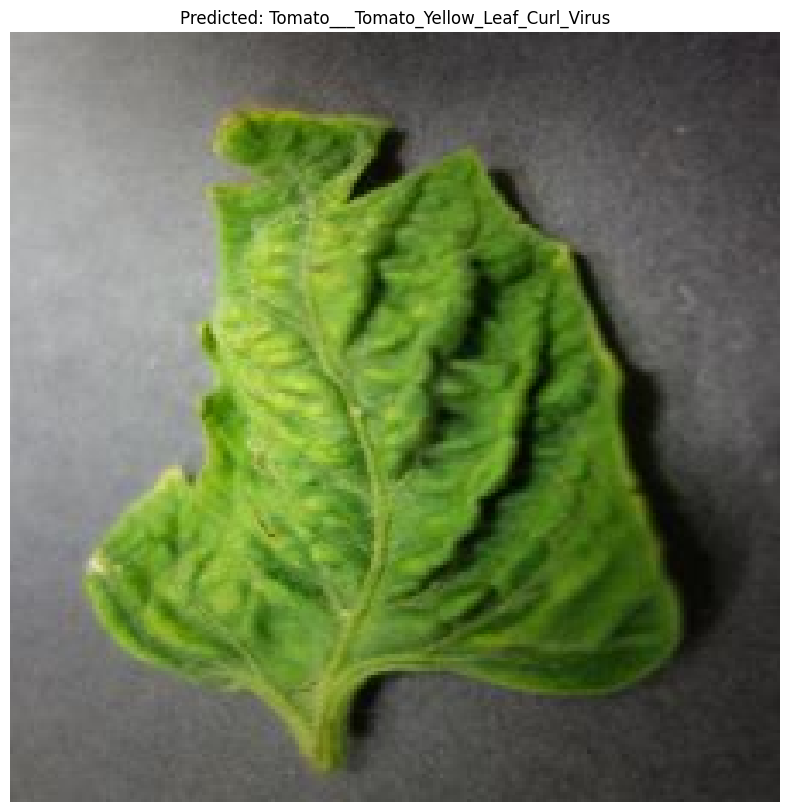


 Predicted class: Tomato___Tomato_Yellow_Leaf_Curl_Virus


In [52]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import json
from PIL import Image
import xgboost as xgb
IMG_SIZE = (224, 224)
FEATURE_BACKBONE = "efficientnetb0"  
MODEL_OUT = "xgb_plant_disease_model.json"
LABELS_OUT = "label_map.json"

#Load label map
with open(LABELS_OUT, "r") as f:
    label_map = json.load(f)
label_map = {int(k): v for k, v in label_map.items()}
xgb_model = xgb.XGBClassifier()
xgb_model.load_model(MODEL_OUT)
if FEATURE_BACKBONE == "efficientnetb0":
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, weights="imagenet", pooling="avg", input_shape=(224,224,3)
    )
    preprocess_input = tf.keras.applications.efficientnet.preprocess_input
elif FEATURE_BACKBONE == "mobilenetv2":
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False, weights="imagenet", pooling="avg", input_shape=(224,224,3)
    )
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
else:
    raise ValueError("Invalid backbone")

# Prediction
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    features = base_model.predict(img_array, verbose=0)
    pred = xgb_model.predict(features)[0]
    probas = xgb_model.predict_proba(features)[0]
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {label_map[pred]}")
    plt.show()

    print(f"\n Predicted class: {label_map[pred]}")
if __name__ == "__main__":
    test_image = "test/test/TomatoYellowCurlVirus4.JPG"   
    predict_image(test_image)


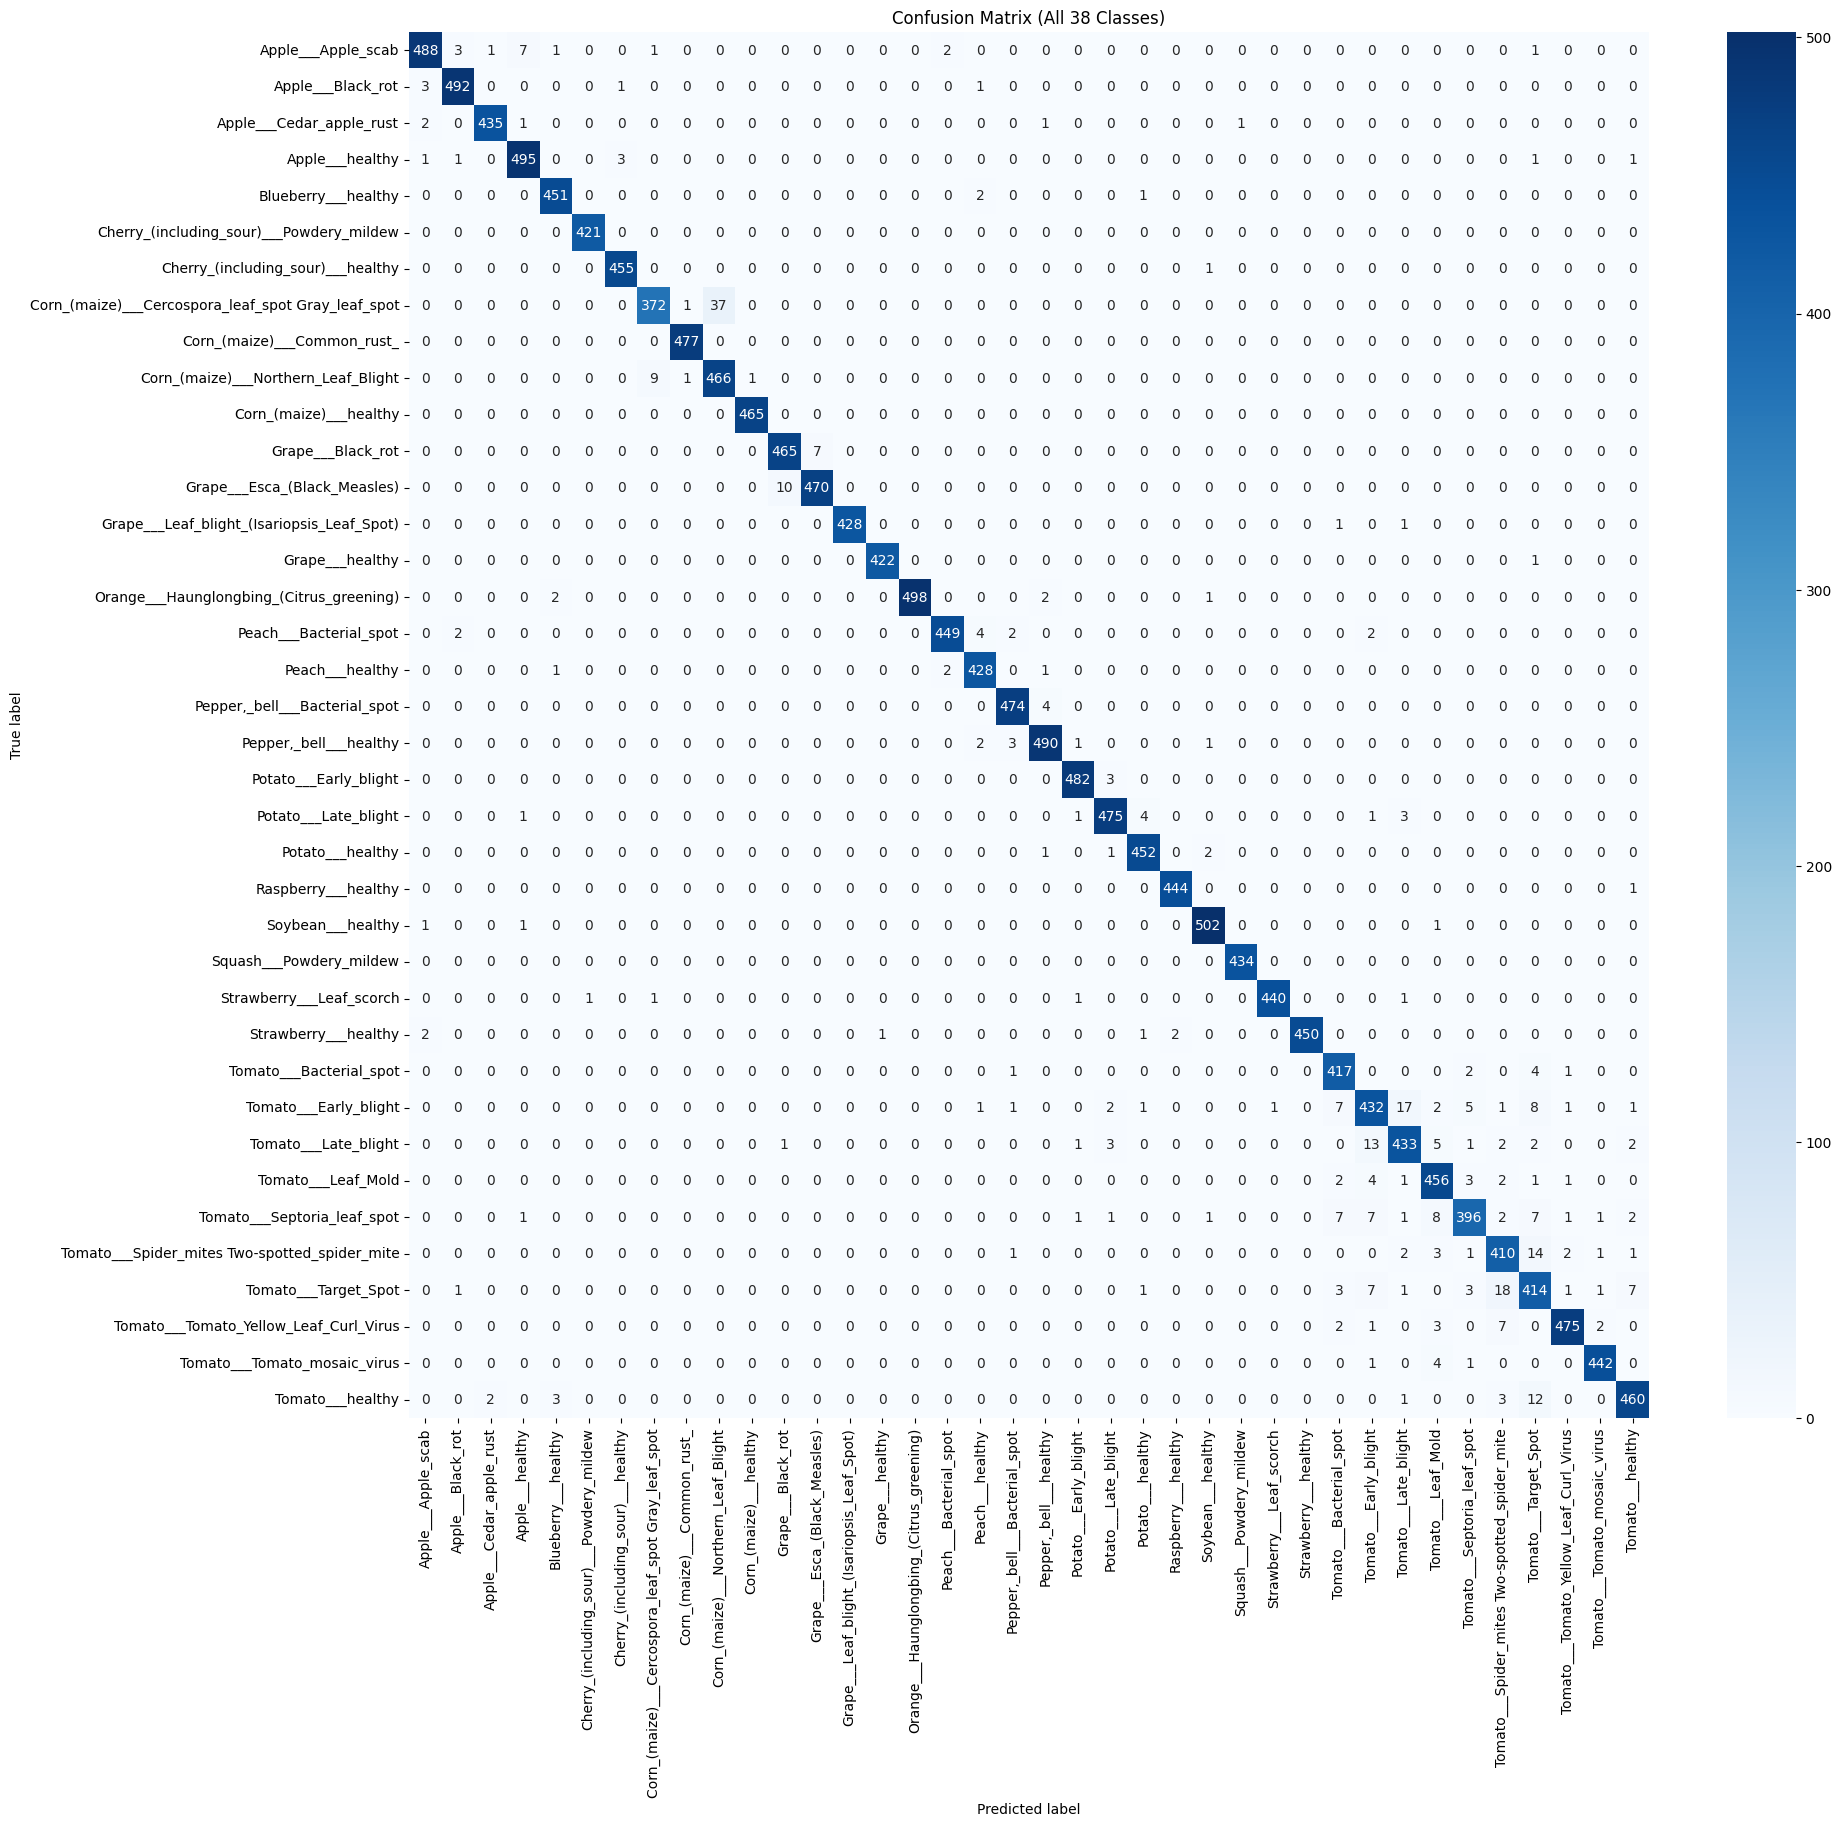

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
valid_pred = model.predict(X_valid)
cm = confusion_matrix(y_valid, valid_pred)
class_names = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust',
    'Apple___healthy', 'Blueberry___healthy',
    'Cherry_(including_sour)___Powdery_mildew',
    'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy', 'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy',
    'Potato___Early_blight', 'Potato___Late_blight',
    'Potato___healthy', 'Raspberry___healthy',
    'Soybean___healthy', 'Squash___Powdery_mildew',
    'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight',
    'Tomato___Late_blight', 'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus', 'Tomato___healthy'
]

# Plot the confusion matrix
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (All 38 Classes)')
plt.show()

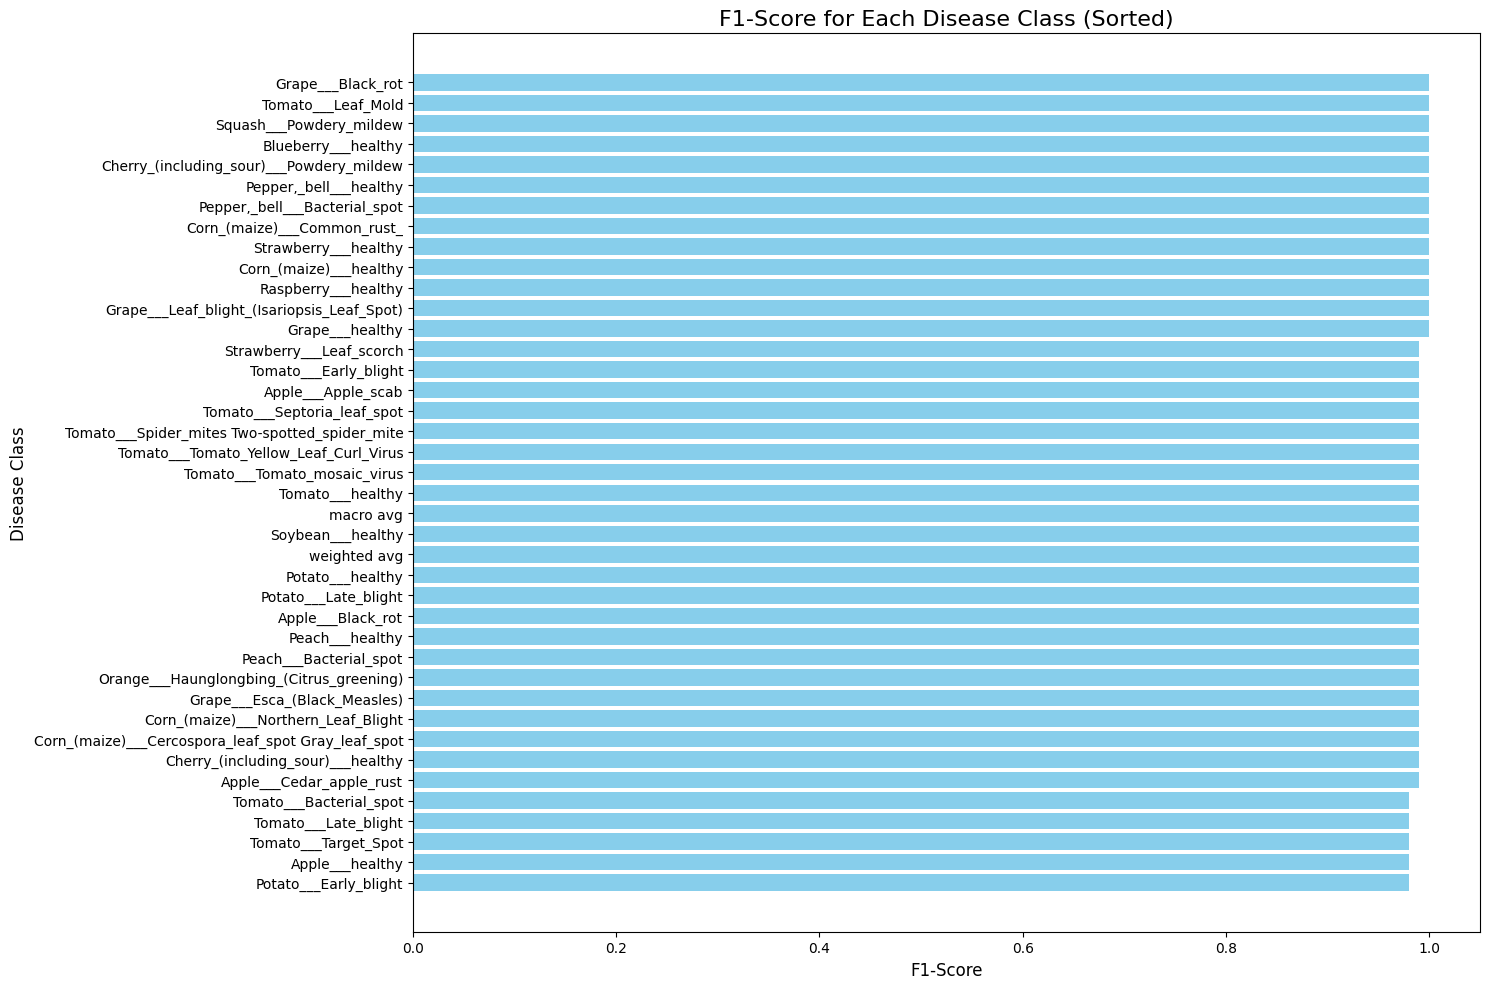

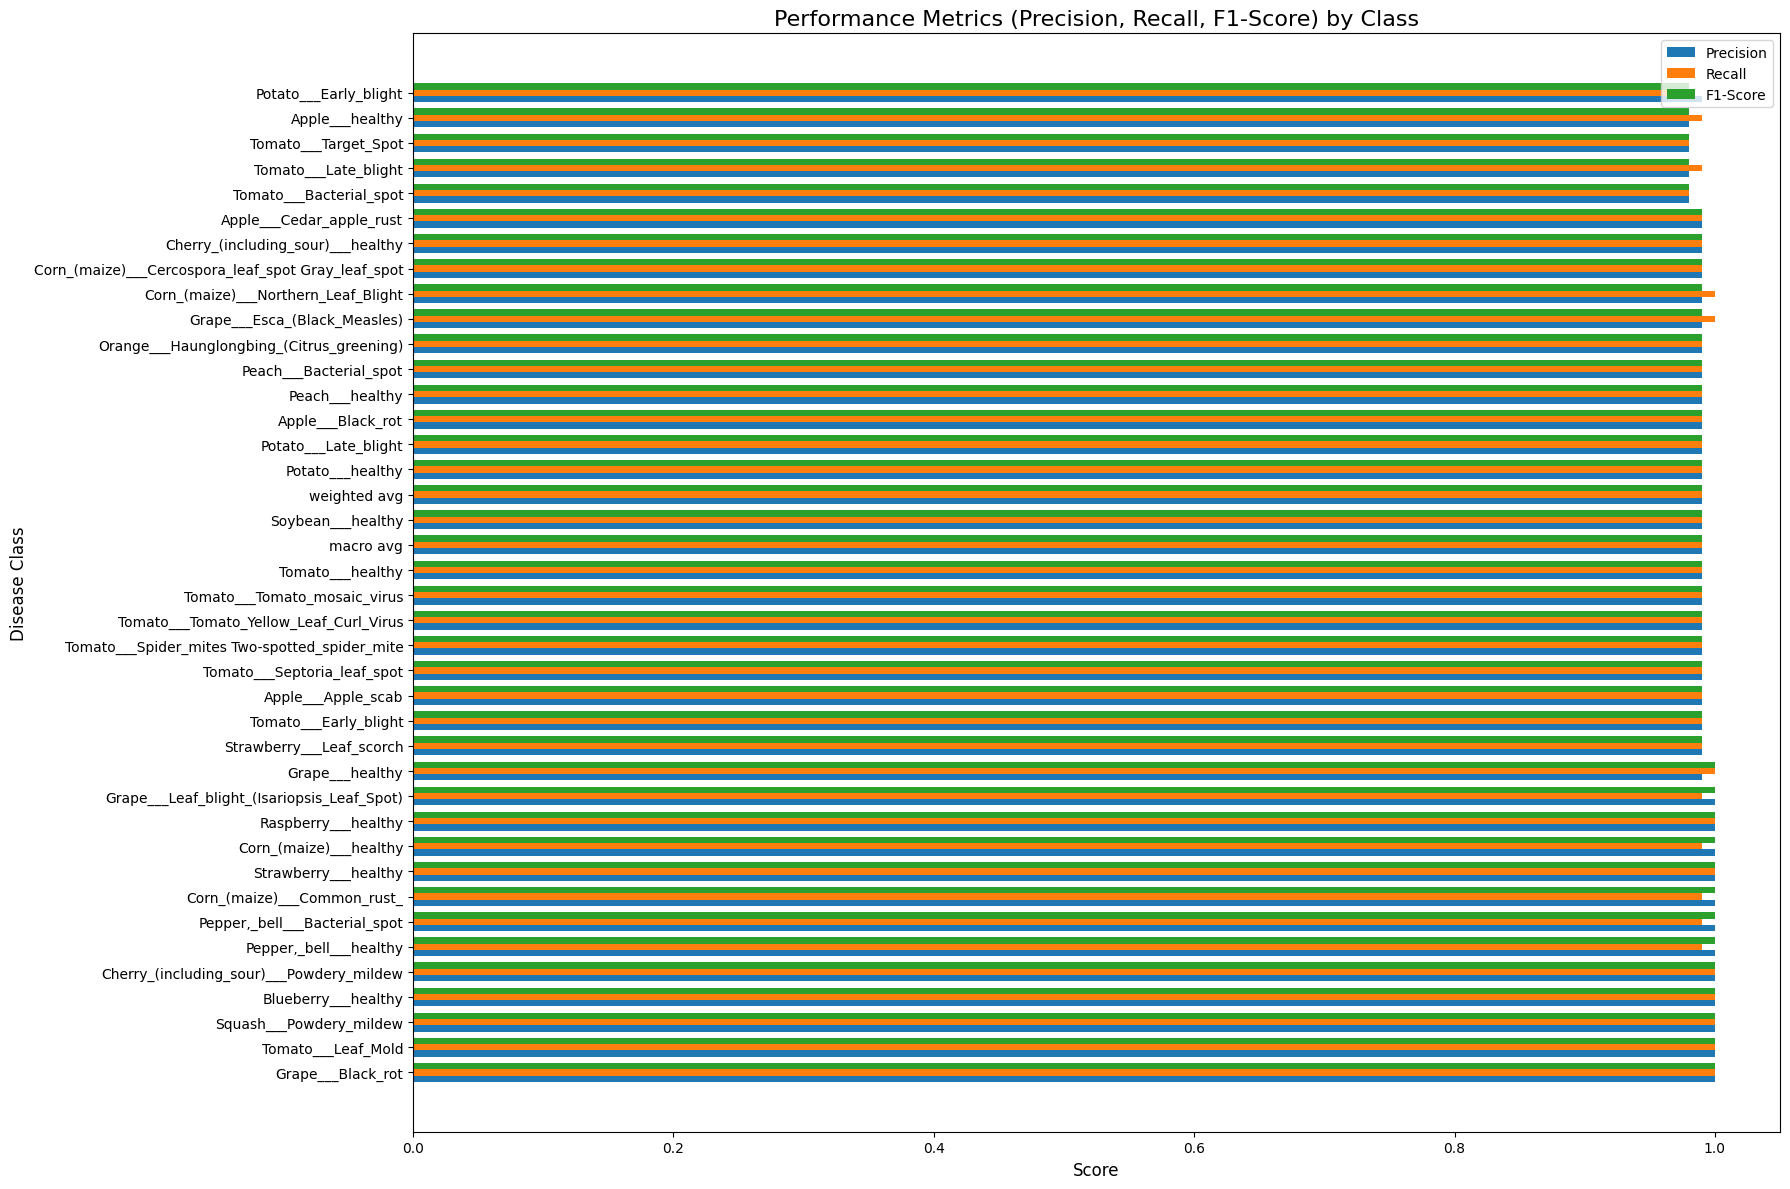

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# The classification report from the notebook output
report_text = """
                                precision    recall  f1-score   support

Apple___Apple_scab       0.99      0.99      0.99       498
Apple___Black_rot       0.99      0.99      0.99       497
Apple___Cedar_apple_rust       0.99      0.99      0.99       497
Apple___healthy       0.98      0.99      0.98       497
Blueberry___healthy       1.00      1.00      1.00       499
Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       497
Cherry_(including_sour)___healthy       0.99      0.99      0.99       499
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.99      0.99      0.99       497
Corn_(maize)___Common_rust_       1.00      0.99      1.00       498
Corn_(maize)___Northern_Leaf_Blight       0.99      1.00      0.99       499
Corn_(maize)___healthy       1.00      0.99      1.00       497
Grape___Black_rot       1.00      1.00      1.00       497
Grape___Esca_(Black_Measles)       0.99      1.00      0.99       497
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      0.99      1.00       498
Grape___healthy       0.99      1.00      1.00       497
Orange___Haunglongbing_(Citrus_greening)       0.99      0.99      0.99       497
Peach___Bacterial_spot       0.99      0.99      0.99       497
Peach___healthy       0.99      0.99      0.99       498
Pepper,_bell___Bacterial_spot       1.00      0.99      1.00       498
Pepper,_bell___healthy       1.00      0.99      1.00       499
Potato___Early_blight       0.99      0.98      0.98       498
Potato___Late_blight       0.99      0.99      0.99       498
Potato___healthy       0.99      0.99      0.99       499
Raspberry___healthy       1.00      1.00      1.00       497
Soybean___healthy       0.99      0.99      0.99       498
Squash___Powdery_mildew       1.00      1.00      1.00       498
Strawberry___Leaf_scorch       0.99      0.99      0.99       499
Strawberry___healthy       1.00      1.00      1.00       497
Tomato___Bacterial_spot       0.98      0.98      0.98       499
Tomato___Early_blight       0.99      0.99      0.99       497
Tomato___Late_blight       0.98      0.99      0.98       497
Tomato___Leaf_Mold       1.00      1.00      1.00       497
Tomato___Septoria_leaf_spot       0.99      0.99      0.99       498
Tomato___Spider_mites Two-spotted_spider_mite       0.99      0.99      0.99       499
Tomato___Target_Spot       0.98      0.98      0.98       498
Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.99      0.99      0.99       499
Tomato___Tomato_mosaic_virus       0.99      0.99      0.99       498
Tomato___healthy       0.99      0.99      0.99       498

accuracy                           0.99      19075
macro avg       0.99      0.99      0.99      19075
weighted avg       0.99      0.99      0.99      19075
"""

# Split the report into lines and filter out header and footer
lines = report_text.strip().split('\n')
data_lines = [line for line in lines if line and not line.strip().startswith(' ') and len(line.split()) > 4]

# Parse the data into lists
labels = []
precision = []
recall = []
f1_score = []

for line in data_lines:
    parts = line.split()
    label = ' '.join(parts[:-4])
    labels.append(label)
    precision.append(float(parts[-4]))
    recall.append(float(parts[-3]))
    f1_score.append(float(parts[-2]))

df = pd.DataFrame({
    'label': labels,
    'precision': precision,
    'recall': recall,
    'f1_score': f1_score
})

# Sort the DataFrame by F1-score for better visualization
df = df.sort_values('f1_score', ascending=False)

# Create the plot
plt.figure(figsize=(15, 10))
plt.barh(df['label'], df['f1_score'], color='skyblue')
plt.xlabel('F1-Score', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
plt.title('F1-Score for Each Disease Class (Sorted)', fontsize=16)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('f1_score_plot.png')

# Create a second plot comparing precision, recall, and f1-score
df_melted = df.melt(id_vars='label', var_name='Metric', value_name='Score', value_vars=['precision', 'recall', 'f1_score'])

plt.figure(figsize=(18, 12))
bar_width = 0.25
index = plt.np.arange(len(df_melted['label'].unique()))

precision_scores = df_melted[df_melted['Metric'] == 'precision']['Score'].values
recall_scores = df_melted[df_melted['Metric'] == 'recall']['Score'].values
f1_scores = df_melted[df_melted['Metric'] == 'f1_score']['Score'].values

plt.barh(index, precision_scores, bar_width, label='Precision')
plt.barh(index + bar_width, recall_scores, bar_width, label='Recall')
plt.barh(index + 2 * bar_width, f1_scores, bar_width, label='F1-Score')

plt.yticks(index + bar_width, df['label'])
plt.xlabel('Score', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)
plt.title('Performance Metrics (Precision, Recall, F1-Score) by Class', fontsize=16)
plt.legend()
plt.tight_layout()
plt.savefig('performance_metrics_plot.png')